Primary Goal of Human in a loop

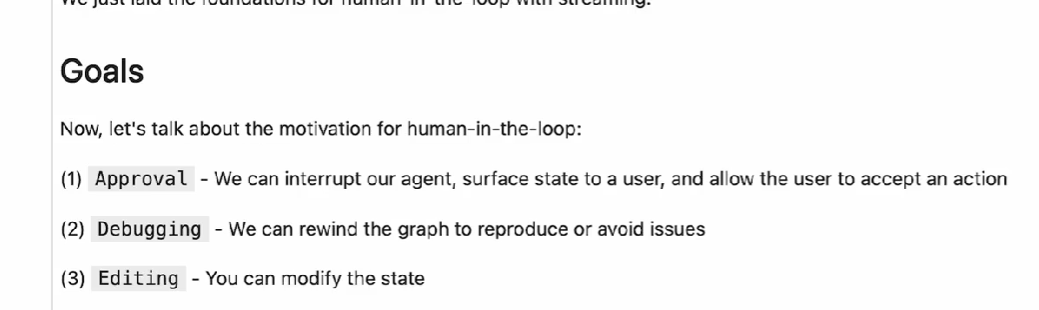

### Huamn Approval before a tool call

In [2]:
import sys
import os

# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

In [3]:
def get_inventory_update() -> str:
    """
    Give the update about the inventory items
    """
    
    return """
    Total Items: 2
    Shoes: 5
    Shocks: 10
    """

    

In [5]:
from get_llm import get_model

def get_llm_with_tools():
    model = get_model()
    llm_with_tools = model.bind_tools([get_inventory_update])
    
    return llm_with_tools

In [7]:
from langgraph.graph import MessagesState

def assistant(state: MessagesState):
    messages = state["messages"]
    model = get_llm_with_tools()
    res = model.invoke(messages)
    return MessagesState(messages=res)

In [38]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode([get_inventory_update]))

builder.add_edge(START, "assistant")
builder.add_edge("tools", "assistant")
builder.add_conditional_edges("assistant", tools_condition)

In [39]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph = builder.compile(checkpointer=memory, interrupt_before=["tools"])

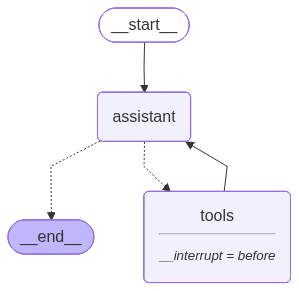

In [40]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
from pretty_print import print_langchain_messages

config = {"configurable" : {"thread_id" : "1"}}

for event in graph.stream({"messages" : "what is total inventary we have ?"}, config=config, stream_mode="values"):
    # print(event)
    print_langchain_messages(event["messages"])

================================ Human Message =================================
what is total inventary we have ?
================================ Human Message =================================
what is total inventary we have ?
================================== Ai Message ==================================
Tool Calls:
  get_inventory_update (4a6a0fcd-d45a-4947-9e50-2e20aa4adc67)
 Call ID: 4a6a0fcd-d45a-4947-9e50-2e20aa4adc67
  Args:


### Here we can see that the state is interupted at tool call

In [42]:
test_config = {"configurable" : {"thread_id" : "1"}}

state = graph.get_state(test_config)

# get_state give the snapshot of the current state of the graph. It returns a StateSnapshot object
state.next

('tools',)

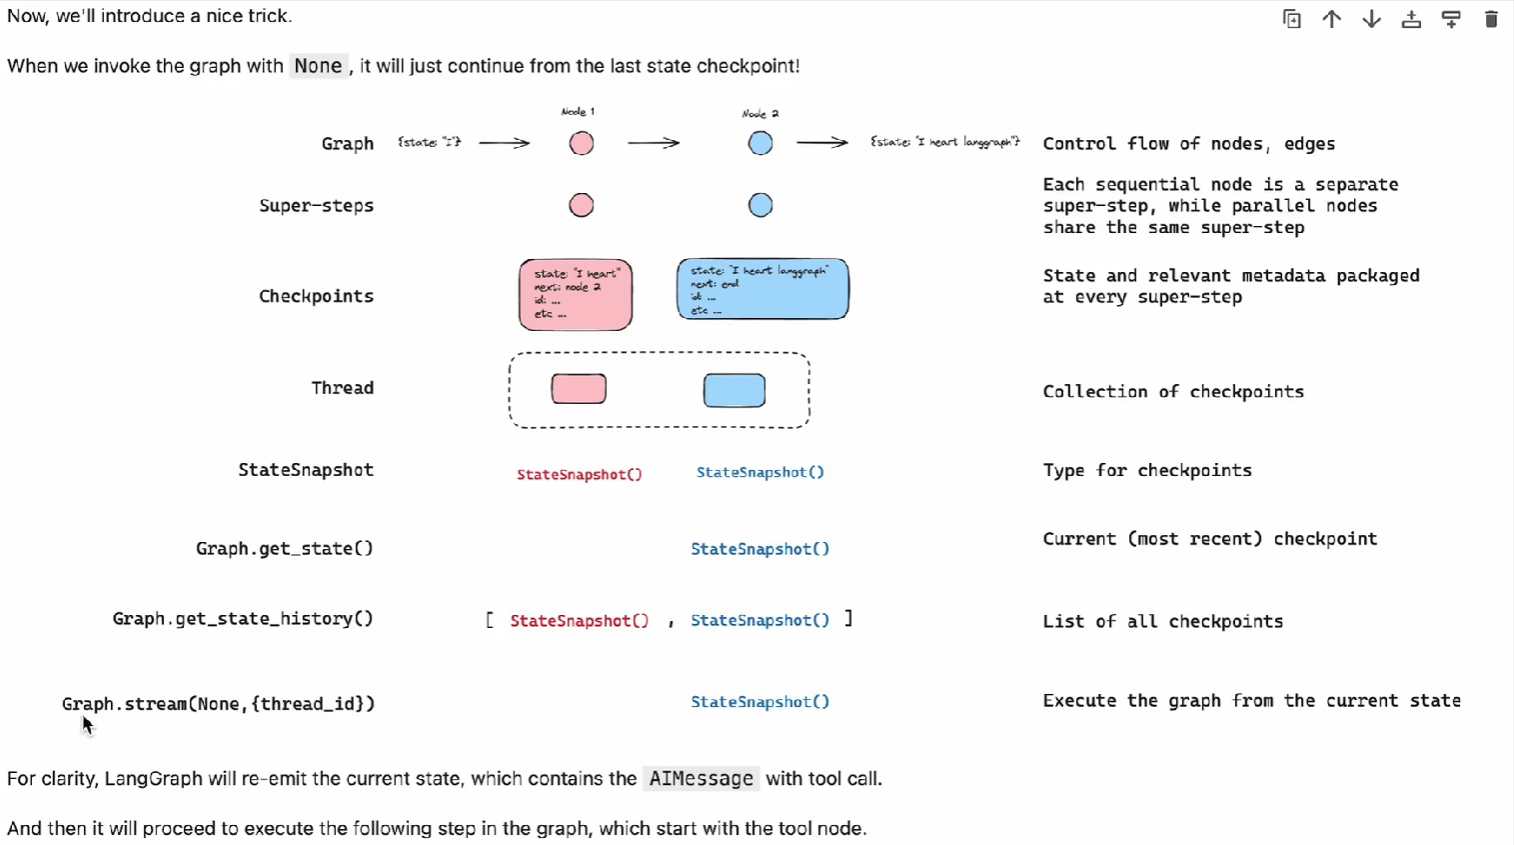

In [43]:
# now lets run the remaining graph.
# when we pass none in current state of the graph and config the graph continues its execution.

retrived_config = {"configurable" : {"thread_id" : "1"}}

for event in graph.stream(None, config=retrived_config, stream_mode="values"):
    # print(event)
    print_langchain_messages(event["messages"])

================================ Human Message =================================
what is total inventary we have ?
================================== Ai Message ==================================
Tool Calls:
  get_inventory_update (4a6a0fcd-d45a-4947-9e50-2e20aa4adc67)
 Call ID: 4a6a0fcd-d45a-4947-9e50-2e20aa4adc67
  Args:
================================ Human Message =================================
what is total inventary we have ?
================================== Ai Message ==================================
Tool Calls:
  get_inventory_update (4a6a0fcd-d45a-4947-9e50-2e20aa4adc67)
 Call ID: 4a6a0fcd-d45a-4947-9e50-2e20aa4adc67
  Args:
================================= Tool Message =================================
Name: get_inventory_update


    Total Items: 2
    Shoes: 5
    Shocks: 10
    
================================ Human Message =================================
what is total inventary we have ?
================================== Ai Message ===========================